# Display Matrix

This notebook shows the differents similarites matrix and compare the correlations between them.

Results are explained in Section 4.3.

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
from utils import (
    compute_shap_ndcg_similarity,
    compute_shap_similarity_pearson,
    compute_lime_ndcg_similarity,
    compute_lime_similarity_pearson,
    plot_heatmaps,
    load_nested_results,
)

from sim_global import compute_similarity_pearson, compute_mae_sim
import pandas as pd
import numpy as np
import scipy.cluster.hierarchy as sch

In [3]:
all_results = load_nested_results("results_all_2/")

In [4]:
all_shap_pearson = []
all_shap_ndcg = []
all_lime_pearson = []
all_lime_ndcg = []
all_pdp_pearsons = []
all_pdp_maes = []
all_ale_pearsons = []
all_ale_maes = []

for dataset_name, results in all_results.items():
    print(dataset_name)

    shap_pearson, model_names = compute_shap_similarity_pearson(results)
    shap_ndcg, _ = compute_shap_ndcg_similarity(results)

    lime_pearson, _ = compute_lime_similarity_pearson(results)
    lime_ndcg, _ = compute_lime_ndcg_similarity(results)

    pdp_pearson, _ = compute_similarity_pearson(results, "pdp_values", "pd_values")
    pdp_mae, _ = compute_mae_sim(results, "pdp_values", "pd_values")

    ale_pearson, _ = compute_similarity_pearson(results, "ale_values", "ale_values")
    ale_mae, _ = compute_mae_sim(results, "ale_values", "ale_values")

    all_shap_pearson.append(shap_pearson)
    all_shap_ndcg.append(shap_ndcg)

    all_lime_pearson.append(lime_pearson)
    all_lime_ndcg.append(lime_ndcg)

    all_pdp_pearsons.append(pdp_pearson)
    all_pdp_maes.append(pdp_mae)

    all_ale_pearsons.append(ale_pearson)
    all_ale_maes.append(ale_mae)

2_annthyroid
4_breastw
14_glass
15_Hepatitis
21_Lymphography
23_mammography
27_PageBlocks
29_Pima
37_Stamps
38_thyroid
39_vertebral
40_vowels
42_WBC
44_Wilt
45_wine
47_yeast


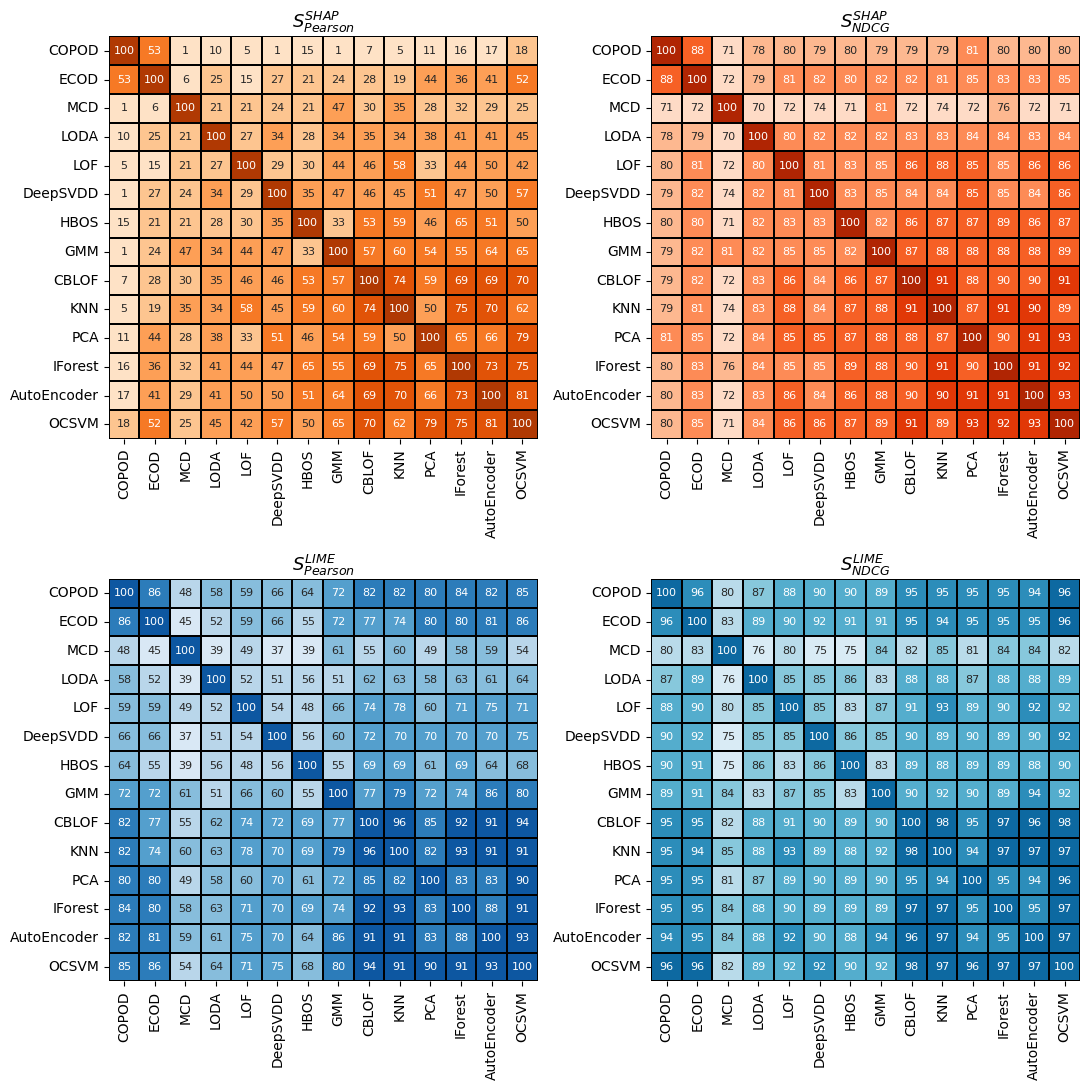

In [13]:
matrices_locales = {
    r"$S^{SHAP}_{Pearson}$": all_shap_pearson,
    r"$S^{SHAP}_{NDCG}$": all_shap_ndcg,
    r"$S^{LIME}_{Pearson}$": all_lime_pearson,
    r"$S^{LIME}_{NDCG}$": all_lime_ndcg,
}

df_dict = {}
for name, mat_list in matrices_locales.items():
    mean_mat = np.nanmean(np.array(mat_list), axis=0)
    df_dict[name] = pd.DataFrame(mean_mat * 100, index=model_names, columns=model_names)

dist_matrix = 100 - df_dict[r"$S^{SHAP}_{Pearson}$"].values
linkage = sch.linkage(dist_matrix, method="average")
dendro = sch.dendrogram(linkage, no_plot=True)
ordered_labels = [df_dict[r"$S^{SHAP}_{Pearson}$"].index[i] for i in dendro["leaves"]]

for name in df_dict:
    df_dict[name] = df_dict[name].loc[ordered_labels, ordered_labels]

fig = plot_heatmaps(
    df_dict,
    figsize=(11, 11),
    colormaps=[
        "Oranges",
        "Blues",
    ],
    hue_shift=-0.02,
)

fig.savefig("matrices_locales.eps", format="eps", bbox_inches="tight", pad_inches=0.1)

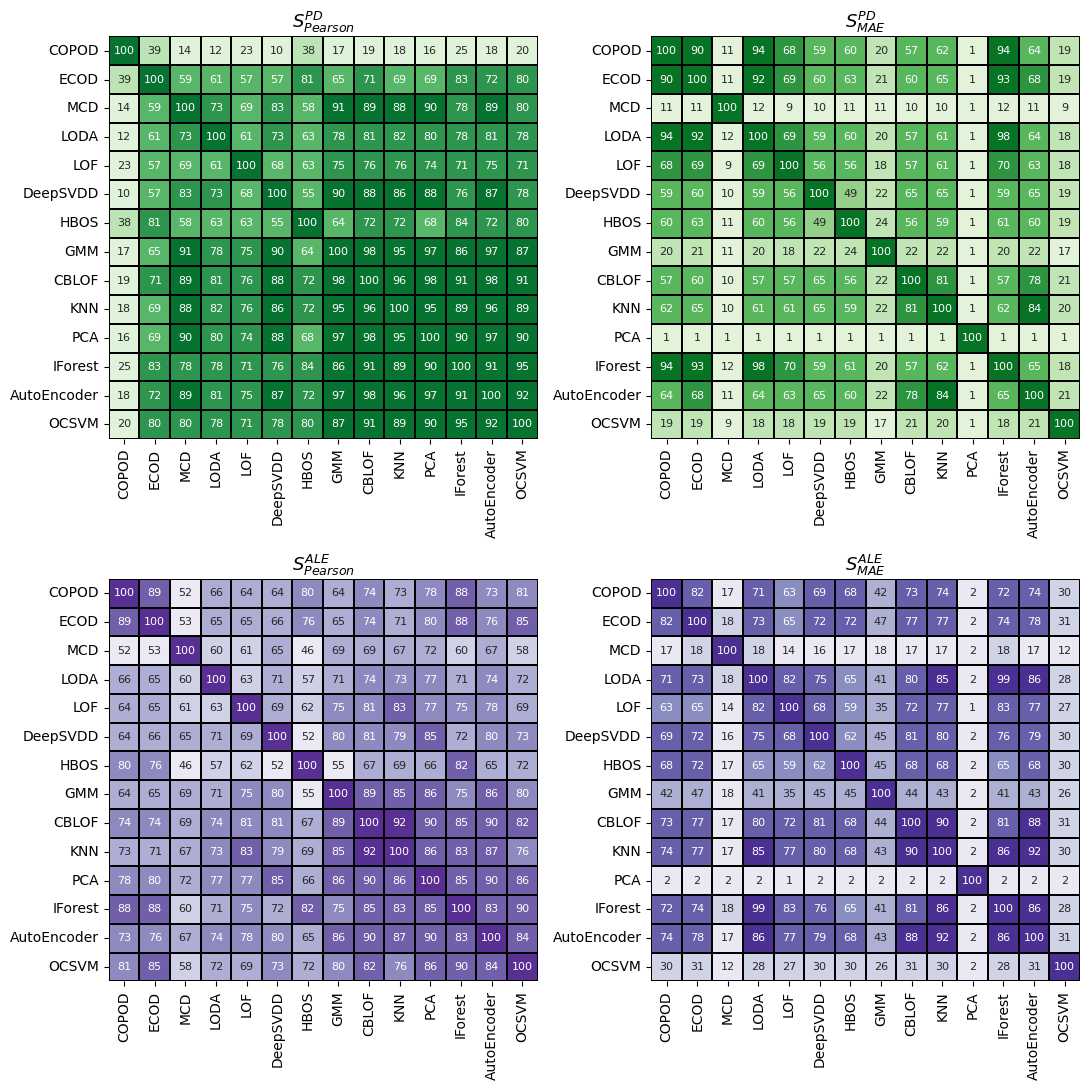

In [15]:
matrices_globales = {
    r"$S^{PD}_{Pearson}$": all_pdp_pearsons,
    r"$S^{PD}_{MAE}$": all_pdp_maes,
    r"$S^{ALE}_{Pearson}$": all_ale_pearsons,
    r"$S^{ALE}_{MAE}$": all_ale_maes,
}


df_dict = {}
for name, mat_list in matrices_globales.items():
    mean_mat = np.nanmean(np.array(mat_list), axis=0)
    df_dict[name] = pd.DataFrame(mean_mat * 100, index=model_names, columns=model_names)

for name in df_dict:
    df_dict[name] = df_dict[name].loc[ordered_labels, ordered_labels]

fig = plot_heatmaps(
    df_dict,
    figsize=(11, 11),
    colormaps=[
        "Greens",
        "Purples",
    ],
    hue_shift=-0.02,
)

fig.savefig("matrices_globales.eps", format="eps", bbox_inches="tight", pad_inches=0.1)

In [17]:
from skbio.stats.distance import mantel

all_matrices = matrices_locales | matrices_globales

matrices_dist = [1 - np.nanmean(m, axis=0) for m in all_matrices.values()]
names = list(all_matrices.keys())

n = len(matrices_dist)
mantel_corrs = np.zeros((n, n))
mantel_pvals = np.zeros((n, n))

for i in range(n):
    for j in range(i, n):
        corr, pval, _ = mantel(matrices_dist[i], matrices_dist[j], permutations=10000)
        mantel_corrs[i, j] = mantel_corrs[j, i] = corr
        mantel_pvals[i, j] = mantel_pvals[j, i] = pval

df_corr = pd.DataFrame(mantel_corrs, index=names, columns=names)
df_pval = pd.DataFrame(mantel_pvals, index=names, columns=names)

print("Mantel correlation matrix:")
print(df_corr.round(2))
print("\n")
print("Mantel p-value matrix:")
print(df_pval.round(3))

Mantel correlation matrix:
                      $S^{SHAP}_{Pearson}$  $S^{SHAP}_{NDCG}$  \
$S^{SHAP}_{Pearson}$                  1.00               0.83   
$S^{SHAP}_{NDCG}$                     0.83               1.00   
$S^{LIME}_{Pearson}$                  0.61               0.74   
$S^{LIME}_{NDCG}$                     0.48               0.74   
$S^{PD}_{Pearson}$                    0.77               0.45   
$S^{PD}_{MAE}$                       -0.08               0.12   
$S^{ALE}_{Pearson}$                   0.65               0.72   
$S^{ALE}_{MAE}$                      -0.01               0.18   

                      $S^{LIME}_{Pearson}$  $S^{LIME}_{NDCG}$  \
$S^{SHAP}_{Pearson}$                  0.61               0.48   
$S^{SHAP}_{NDCG}$                     0.74               0.74   
$S^{LIME}_{Pearson}$                  1.00               0.94   
$S^{LIME}_{NDCG}$                     0.94               1.00   
$S^{PD}_{Pearson}$                    0.18               0.07 

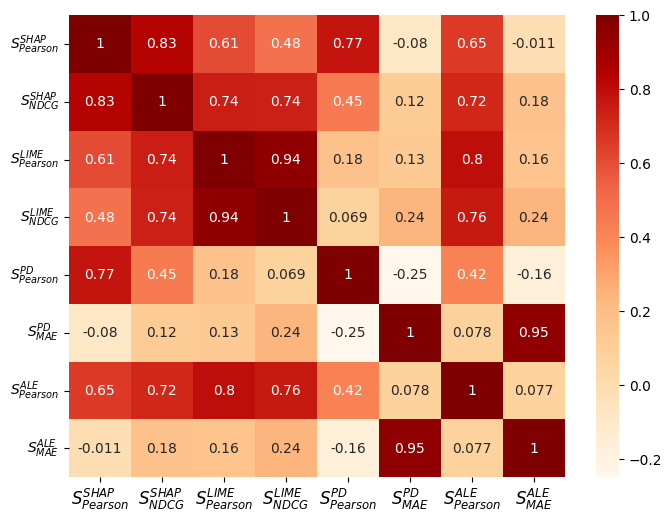

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))


g = sns.heatmap(df_corr, annot=True, cmap="OrRd", ax=ax)

g.set_xticklabels(g.get_xmajorticklabels(), fontsize=12)
g.set_yticklabels(g.get_ymajorticklabels(), fontsize=12)

plt.yticks(rotation=0)

fig.savefig("corr.eps", format="eps", bbox_inches="tight", pad_inches=0.1)

# Close the figure to free up memory, especially if running in a loop
# plt.close(fig)

In [ ]:
dataset_names = list(all_results.keys())

correlations = {}

for i, dataset_name in enumerate(dataset_names):

    matrices_dist = [1 - all_matrices[name][i] for name in all_matrices.keys()]

    correlations[dataset_name] = [
        mantel(matrices_dist[0], matrices_dist[2])[0],
        mantel(matrices_dist[0], matrices_dist[3])[0],
    ]


df = pd.DataFrame.from_dict(
    correlations, orient="index", columns=["corr(pshap_pscores)", "corr(pshap_jaccard)"]
)
df[["corr(pshap_pscores)", "corr(pshap_jaccard)"]] *= 100

df.round()